# Irrigation Modeling — Pump 1 (Binary Classification)

This notebook trains baseline ML models (Logistic Regression, Random Forest, KNN) and a small Neural Network to predict **Pump_1 ON/OFF** using greenhouse sensor features.

**Split:** Train/Val/Test = **70/15/15** (stratified, fixed seed).

In [ ]:
import os, glob, re, math, random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [ ]:
DATA_PATH = "/content/data_clean 2.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

rename_map = {
    "Temperature, C": "Temp_C",
    "Humidity, %": "RH_pct",
    "Illumination, lx": "Lux",
    "CO, ppm": "CO_ppm",
    "Pressure, MPa": "Pressure_MPa",
    "Solution temperature, C": "SolTemp_C",
    "Solution acidity, pH": "pH",
    "Solution conductivity, S/cm": "Cond_Scm",
    "Battery, V": "Battery_V",
    "Air circulation": "Air_circulation",
    "Vcc, V": "Vcc_V",
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})

print("Shape:", df.shape)
df.head()

Shape: (30227, 22)


,Timestamp,Temp_C,RH_pct,Lux,CO_ppm,Pressure_MPa,SolTemp_C,pH,Cond_Scm,Heater,...,Air_circulation,Ground,Fog,Pump 1,Pump 2,Valve 1,Valve 2,Battery_V,Vcc_V,Version
0,2025-05-17 12:49:00,26.7,74,5855,1394.0,0.315,13.8,7.0,406,0,...,0,0,0,1,0,0,0,4.068,11.946,2.6/1.8
1,2025-05-17 12:50:00,27.4,74,6828,1402.0,0.314,14.2,7.0,408,0,...,0,0,0,0,0,0,0,4.068,11.946,2.6/1.8
2,2025-05-17 12:51:00,28.1,73,6802,1397.0,0.010,14.2,7.0,408,0,...,0,0,1,0,0,0,0,4.068,11.964,2.6/1.8
3,2025-05-17 12:52:00,28.4,72,6760,1387.0,0.010,14.3,7.0,404,0,...,0,0,1,0,0,0,0,4.068,11.946,2.6/1.8
4,2025-05-17 12:53:00,29.0,71,9205,1397.0,0.010,14.1,7.0,409,0,...,0,0,1,1,0,0,0,4.068,11.942,2.6/1.8


In [ ]:
df.dropna(inplace=True)

In [ ]:
target_cols = ["Pump 1"]

drop_cols = ["Timestamp", "Version"] + target_cols
X_cols = [c for c in df.columns if c not in drop_cols]

print("X_cols:", X_cols)
print("Targets:", target_cols)


X_cols: ['Temp_C', 'RH_pct', 'Lux', 'CO_ppm', 'Pressure_MPa', 'SolTemp_C', 'pH', 'Cond_Scm', 'Heater', 'Lighting', 'Ventilation', 'Air_circulation', 'Ground', 'Fog', 'Pump 2', 'Valve 1', 'Valve 2', 'Battery_V', 'Vcc_V']
Targets: ['Pump 1']


In [ ]:
if "Temp_C" in df.columns and "RH_pct" in df.columns:
    T = df["Temp_C"].astype(float)
    RH = df["RH_pct"].astype(float)
    svp = 0.6108 * np.exp((17.27 * T) / (T + 237.3))
    df["VPD_kPa"] = svp * (1 - RH/100.0)
    if "VPD_kPa" not in X_cols:
        X_cols.append("VPD_kPa")

df[["Temp_C","RH_pct","VPD_kPa"]].head()

,Temp_C,RH_pct,VPD_kPa
0,26.7,74,0.910798
1,27.4,74,0.948966
2,28.1,73,1.026539
3,28.4,72,1.083282
4,29.0,71,1.161647


In [ ]:
X = df[X_cols]
y = df[target_cols]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print("Split sizes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Split sizes:
Train: (21102, 20) Val: (4522, 20) Test: (4522, 20)


In [ ]:
def evaluate_binary_classifier(model, X_eval, y_eval, name="Model"):
    y_pred = model.predict(X_eval)
    out = {
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
    }
    try:
        y_prob = model.predict_proba(X_eval)[:, 1]
        out["roc_auc"] = roc_auc_score(y_eval, y_prob)
    except Exception:
        out["roc_auc"] = np.nan

    print(f"\n==== {name} ====")
    print(pd.Series(out).round(4))
    print("\nClassification report:")
    print(classification_report(y_eval, y_pred, digits=4))

    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["OFF", "ON"])
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.grid(False)
    plt.show()

    return out

## Baseline Models
We fit three baselines and compare performance on **Validation** first, then report final performance on **Test**.

In [ ]:
# 1) Logistic Regression with scaling
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED))
])
logreg.fit(X_train, y_train)

# 2) Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=SEED,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 3) KNN with scaling
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=15))
])
knn.fit(X_train, y_train)

models = {
    "LogReg": logreg,
    "RandomForest": rf,
    "KNN": knn
}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


## Validation evaluation


==== LogReg (Val) ====
accuracy     0.7096
precision    0.6109
recall       0.4392
f1           0.5110
roc_auc      0.7542
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.7423    0.8524    0.7935      2960
           1     0.6109    0.4392    0.5110      1562

    accuracy                         0.7096      4522
   macro avg     0.6766    0.6458    0.6523      4522
weighted avg     0.6969    0.7096    0.6959      4522



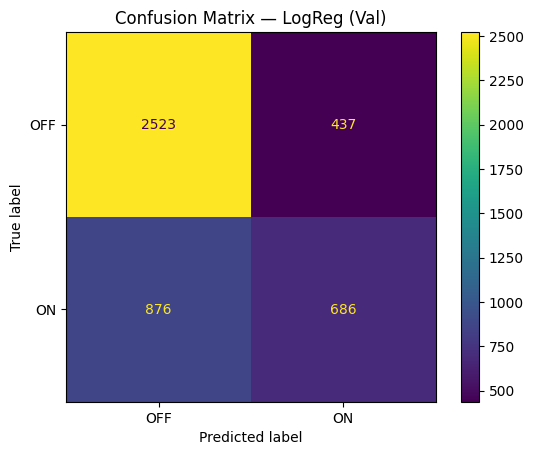


==== RandomForest (Val) ====
accuracy     0.8640
precision    0.8337
recall       0.7574
f1           0.7937
roc_auc      0.9321
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.8779    0.9203    0.8986      2960
           1     0.8337    0.7574    0.7937      1562

    accuracy                         0.8640      4522
   macro avg     0.8558    0.8388    0.8461      4522
weighted avg     0.8626    0.8640    0.8623      4522



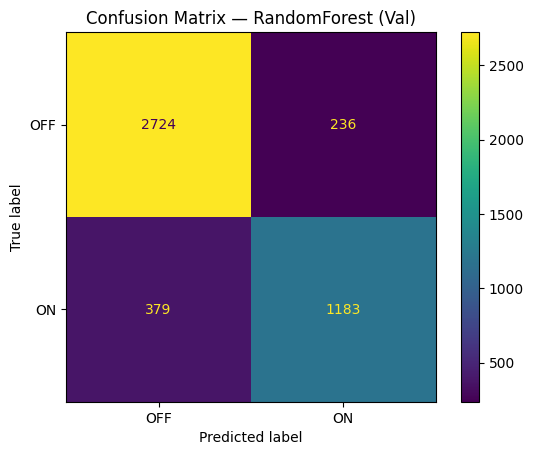


==== KNN (Val) ====
accuracy     0.7293
precision    0.6406
recall       0.4930
f1           0.5572
roc_auc      0.7789
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.7614    0.8541    0.8051      2960
           1     0.6406    0.4930    0.5572      1562

    accuracy                         0.7293      4522
   macro avg     0.7010    0.6735    0.6811      4522
weighted avg     0.7197    0.7293    0.7195      4522



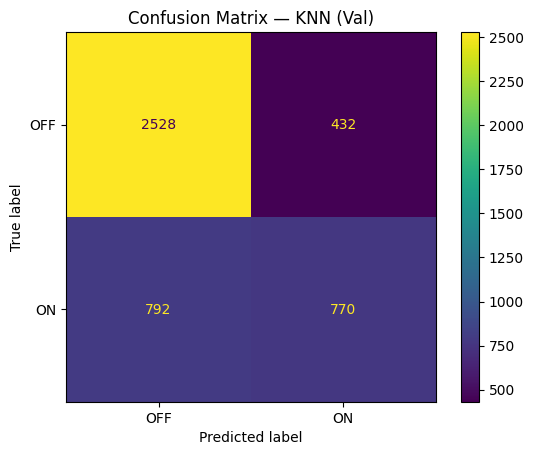

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.863998,0.833686,0.757362,0.793693,0.932126
KNN,0.729323,0.640599,0.492958,0.557164,0.778856
LogReg,0.709642,0.610864,0.439181,0.510987,0.754242


In [ ]:
val_metrics = {}
for name, m in models.items():
    val_metrics[name] = evaluate_binary_classifier(m, X_val, y_val, name=f"{name} (Val)")

val_metrics_df = pd.DataFrame(val_metrics).T.sort_values("f1", ascending=False)
val_metrics_df

## Baseline Evaluation on Test Set


==== LogReg (Test) ====
accuracy     0.7218
precision    0.6305
recall       0.4689
f1           0.5378
roc_auc      0.7667
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.7533    0.8551    0.8010      2961
           1     0.6305    0.4689    0.5378      1561

    accuracy                         0.7218      4522
   macro avg     0.6919    0.6620    0.6694      4522
weighted avg     0.7109    0.7218    0.7102      4522



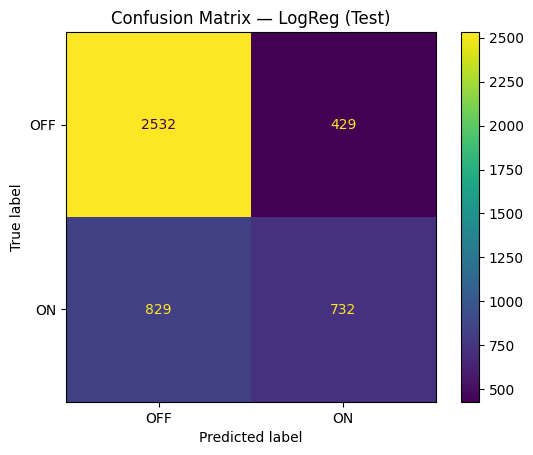


==== RandomForest (Test) ====
accuracy     0.8686
precision    0.8346
recall       0.7726
f1           0.8024
roc_auc      0.9336
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.8846    0.9193    0.9016      2961
           1     0.8346    0.7726    0.8024      1561

    accuracy                         0.8686      4522
   macro avg     0.8596    0.8459    0.8520      4522
weighted avg     0.8674    0.8686    0.8674      4522



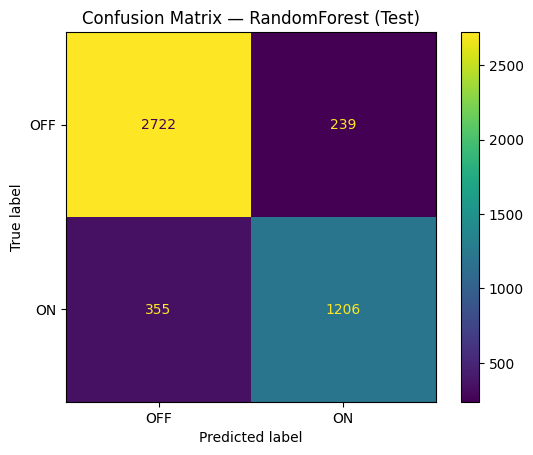


==== KNN (Test) ====
accuracy     0.7444
precision    0.6564
recall       0.5445
f1           0.5952
roc_auc      0.7973
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.7797    0.8497    0.8132      2961
           1     0.6564    0.5445    0.5952      1561

    accuracy                         0.7444      4522
   macro avg     0.7180    0.6971    0.7042      4522
weighted avg     0.7371    0.7444    0.7380      4522



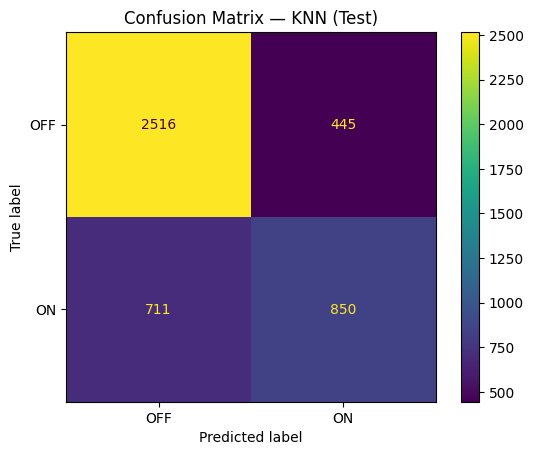

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.868642,0.834602,0.772582,0.802395,0.933607
KNN,0.744361,0.656371,0.544523,0.595238,0.797318
LogReg,0.721805,0.630491,0.468930,0.537840,0.766718


In [ ]:
test_metrics = {}
for name, m in models.items():
    test_metrics[name] = evaluate_binary_classifier(m, X_test, y_test, name=f"{name} (Test)")

test_metrics_df = pd.DataFrame(test_metrics).T.sort_values("f1", ascending=False)
test_metrics_df

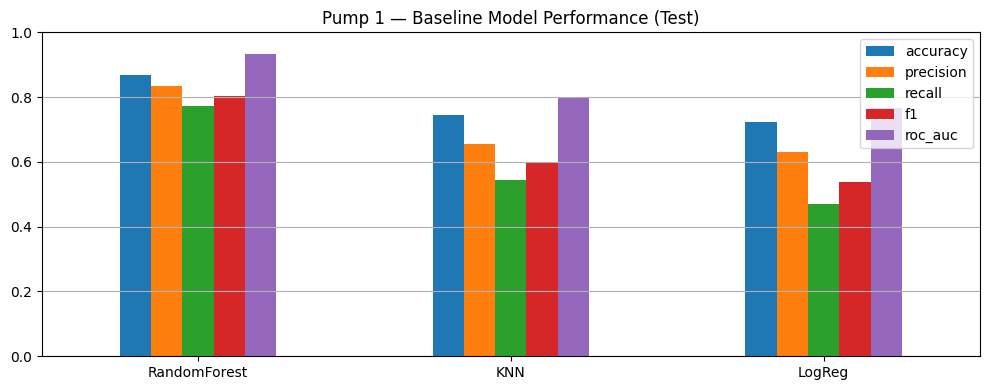

In [ ]:
ax = test_metrics_df[["accuracy","precision","recall","f1","roc_auc"]].plot(kind="bar", figsize=(10,4))
plt.title("Pump 1 — Baseline Model Performance (Test)")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Small Neural Network

We train a lightweight MLP using PyTorch with **BCEWithLogitsLoss**.  
Inputs are standardized using a scaler fit on the **training** split only.

In [ ]:
scaler_nn = StandardScaler()
X_train_s = scaler_nn.fit_transform(X_train)
X_val_s   = scaler_nn.transform(X_val)
X_test_s  = scaler_nn.transform(X_test)

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32)

train_ds = TensorDataset(to_tensor(X_train_s), torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1))
val_ds   = TensorDataset(to_tensor(X_val_s),   torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1))
test_ds  = TensorDataset(to_tensor(X_test_s),  torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1))

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(DEVICE)
print("pos_weight:", pos_weight.item())

pos_weight: 1.8954445123672485


/tmp/ipykernel_718/176352735.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos = float((y_train == 1).sum())
/tmp/ipykernel_718/176352735.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  neg = float((y_train == 0).sum())


In [ ]:
class SmallBinaryMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

model_nn = SmallBinaryMLP(in_dim=X_train.shape[1]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
def eval_nn(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb).cpu().numpy().reshape(-1)
            prob = 1 / (1 + np.exp(-logits))
            ys.append(yb.numpy().reshape(-1))
            ps.append(prob)
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    y_pred = (y_prob >= 0.5).astype(int)
    return y_true.astype(int), y_pred, y_prob

def metrics_from_preds(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    }

In [ ]:
EPOCHS = 50
patience = 8
best_f1 = -1
best_state = None
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model_nn.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model_nn(xb)
        # print(f'logits shape: {logits.shape}, yb shape: {yb.shape}')
        loss = criterion(logits, yb.squeeze(dim=1))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # val
    yv_true, yv_pred, yv_prob = eval_nn(model_nn, val_loader)
    val_m = metrics_from_preds(yv_true, yv_pred, yv_prob)
    tr_loss = float(np.mean(train_losses))

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_f1={val_m['f1']:.4f} | val_acc={val_m['accuracy']:.4f}")

    if val_m["f1"] > best_f1 + 1e-4:
        best_f1 = val_m["f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in model_nn.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping.")
            break

# restore best
if best_state is not None:
    model_nn.load_state_dict(best_state)

print("Best Val F1:", best_f1)

Epoch 01 | train_loss=0.8820 | val_f1=0.5291 | val_acc=0.6154
Epoch 02 | train_loss=0.8294 | val_f1=0.5819 | val_acc=0.6568
Epoch 03 | train_loss=0.7901 | val_f1=0.6047 | val_acc=0.6754
Epoch 04 | train_loss=0.7647 | val_f1=0.6167 | val_acc=0.6891
Epoch 05 | train_loss=0.7559 | val_f1=0.6227 | val_acc=0.6860
Epoch 06 | train_loss=0.7494 | val_f1=0.6230 | val_acc=0.6904
Epoch 07 | train_loss=0.7447 | val_f1=0.6234 | val_acc=0.6986
Epoch 08 | train_loss=0.7418 | val_f1=0.6263 | val_acc=0.6847
Epoch 09 | train_loss=0.7383 | val_f1=0.6295 | val_acc=0.6915
Epoch 10 | train_loss=0.7360 | val_f1=0.6313 | val_acc=0.7046
Epoch 11 | train_loss=0.7337 | val_f1=0.6324 | val_acc=0.6946
Epoch 12 | train_loss=0.7333 | val_f1=0.6336 | val_acc=0.6992
Epoch 13 | train_loss=0.7307 | val_f1=0.6328 | val_acc=0.6928
Epoch 14 | train_loss=0.7293 | val_f1=0.6375 | val_acc=0.7028
Epoch 15 | train_loss=0.7277 | val_f1=0.6389 | val_acc=0.7063
Epoch 16 | train_loss=0.7251 | val_f1=0.6388 | val_acc=0.6944
Epoch 17


==== Small NN (Val) ====
accuracy     0.8187
precision    0.7279
recall       0.7586
f1           0.7429
roc_auc      0.8699
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.8697    0.8503    0.8599      2960
           1     0.7279    0.7586    0.7429      1562

    accuracy                         0.8187      4522
   macro avg     0.7988    0.8045    0.8014      4522
weighted avg     0.8207    0.8187    0.8195      4522



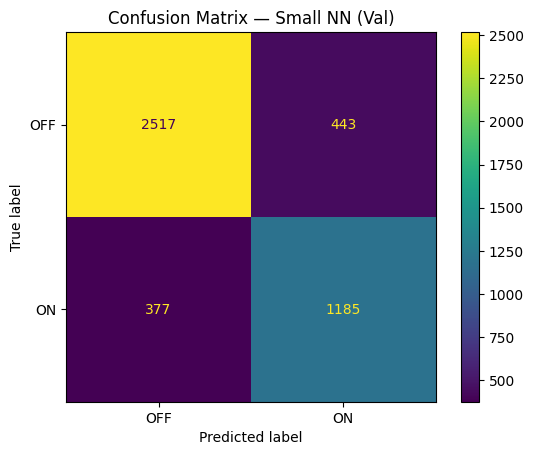


==== Small NN (Test) ====
accuracy     0.8085
precision    0.7118
recall       0.7482
f1           0.7295
roc_auc      0.8730
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.8636    0.8403    0.8518      2961
           1     0.7118    0.7482    0.7295      1561

    accuracy                         0.8085      4522
   macro avg     0.7877    0.7942    0.7907      4522
weighted avg     0.8112    0.8085    0.8096      4522



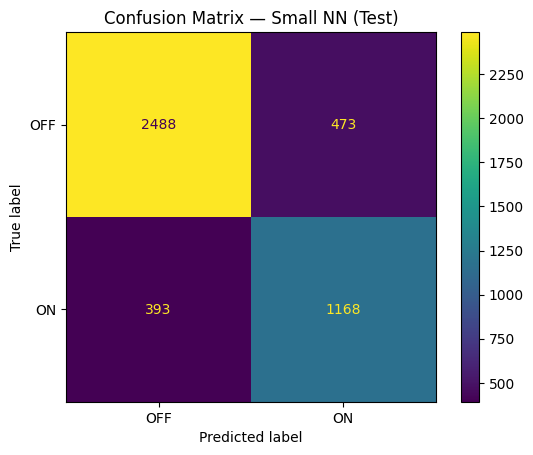

In [ ]:
y_val_true, y_val_pred, y_val_prob = eval_nn(model_nn, val_loader)
val_nn = metrics_from_preds(y_val_true, y_val_pred, y_val_prob)

print("\n==== Small NN (Val) ====")
print(pd.Series(val_nn).round(4))
print("\nClassification report:")
print(classification_report(y_val_true, y_val_pred, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_val_true, y_val_pred), display_labels=["OFF","ON"]).plot()
plt.title("Confusion Matrix — Small NN (Val)")
plt.grid(False)
plt.show()

y_test_true, y_test_pred, y_test_prob = eval_nn(model_nn, test_loader)
test_nn = metrics_from_preds(y_test_true, y_test_pred, y_test_prob)

print("\n==== Small NN (Test) ====")
print(pd.Series(test_nn).round(4))
print("\nClassification report:")
print(classification_report(y_test_true, y_test_pred, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_test_true, y_test_pred), display_labels=["OFF","ON"]).plot()
plt.title("Confusion Matrix — Small NN (Test)")
plt.grid(False)
plt.show()

In [ ]:
all_test = test_metrics_df.copy()
all_test.loc["SmallNN"] = test_nn
all_test = all_test.sort_values("f1", ascending=False)
all_test

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.868642,0.834602,0.772582,0.802395,0.933607
SmallNN,0.808492,0.711761,0.748238,0.729544,0.872991
KNN,0.744361,0.656371,0.544523,0.595238,0.797318
LogReg,0.721805,0.630491,0.468930,0.537840,0.766718


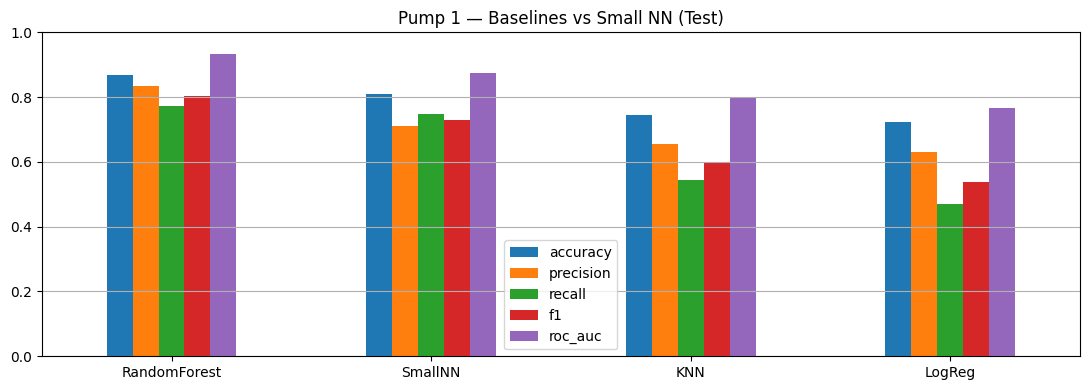

In [ ]:
ax = all_test[["accuracy","precision","recall","f1","roc_auc"]].plot(kind="bar", figsize=(11,4))
plt.title("Pump 1 — Baselines vs Small NN (Test)")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

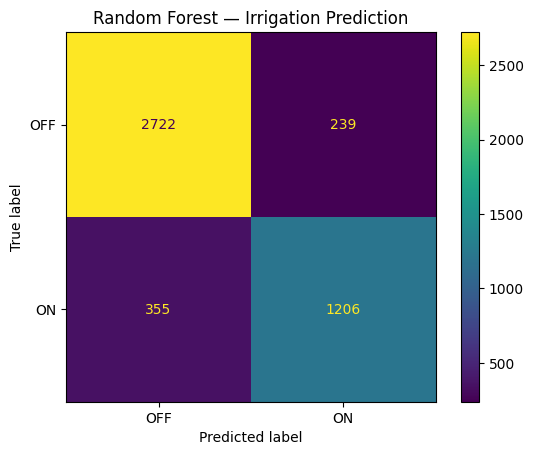

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

rf_model = models["RandomForest"]
y_pred = rf_model.predict(X_test)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["OFF", "ON"]
).plot()

plt.title("Random Forest — Irrigation Prediction")
plt.grid(False)
plt.show()

Random Forest Accuracy: 0.8686
Random Forest F1 Score: 0.8024


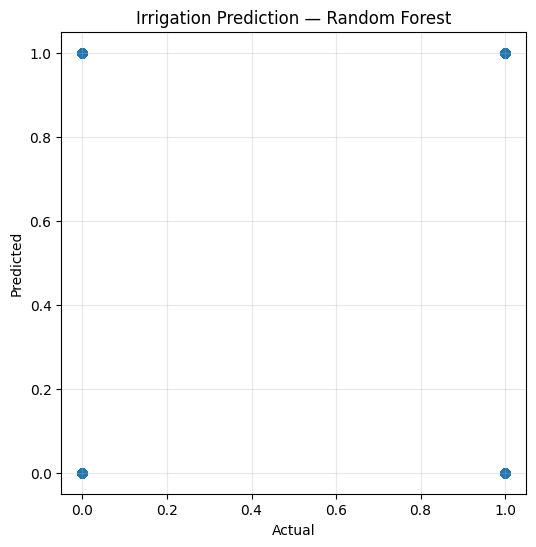

In [ ]:
# Random Forest predictions on test set
rf_model = models["RandomForest"]

y_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Accuracy:", round(acc, 4))
print("Random Forest F1 Score:", round(f1, 4))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Irrigation Prediction — Random Forest")
plt.grid(alpha=0.3)
plt.show()